# 🏥 Data Analytics 101: Análisis de Readmisiones Hospitalarias
## Universidad Iberoamericana, Ciudad de México

---

### Contexto del Proyecto
El hospital enfrenta un desafío operativo crucial: su tasa de readmisiones no planificadas de pacientes diabéticos dentro de 30 días posteriores al alta es una preocupación principal que impacta negativamente el bienestar del paciente y conlleva costosas penalizaciones regulatorias.

**Objetivos de este análisis:**
1. Comprender la estructura, calidad y limitaciones del conjunto de datos
2. Realizar un EDA profundo identificando patrones en readmisiones, recurrencia hospitalaria y duración de estancias
3. Aplicar pruebas estadísticas formales para evaluar hipótesis relevantes
4. Desarrollar modelos estadísticos interpretables para cada fenómeno clínico
5. Comunicar hallazgos clave y recomendaciones de negocio

---

## Setup, Importación de librerias

In [1]:
#FinalProject
#Developer; Andrick Raya
#Course; DA 101
# Librerías de datos y cálculo
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (
    ttest_ind, mannwhitneyu, f_oneway, kruskal, 
    chi2_contingency, kstest, shapiro, levene,
    poisson, nbinom
)

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de machine learning y estadística
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, PoissonRegressor
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
df= pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Mostrar información básica
print("📋 INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Dimensiones: {df.shape}")
print(f"Número de registros (admisiones): {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")
print(f"\nPrimeras filas del dataset:")
print(df.head())
print(f"\nÚltimas filas del dataset:")
print(df.tail())

📋 INFORMACIÓN DEL DATASET
Dimensiones: (101766, 50)
Número de registros (admisiones): 101,766
Número de variables: 50

Primeras filas del dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1             

In [4]:
# Información detallada sobre las columnas
print("📊 TIPO DE DATOS Y VALORES FALTANTES")
print("="*80)
print(df.info())

print("\n📈 DESCRIPCIÓN ESTADÍSTICA - VARIABLES NUMÉRICAS")
print("="*80)
print(df.describe())

print("\n📋 DESCRIPCIÓN - VARIABLES CATEGÓRICAS")
print("="*80)
print(df.describe(include='object'))

📊 TIPO DE DATOS Y VALORES FALTANTES
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64


In [6]:
# Variables de interés según la rúbrica
print("🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS")
print("="*80)

variables_interes = {
    'readmitted': 'Indica si el paciente fue readmitido en los siguientes 30 días',
    'time_in_hospital': 'Días de estancia hospitalaria',
    'number_inpatient': 'Número de admisiones previas en el último año',
    'diag_1': 'Diagnóstico principal (código ICD-9)',
    'diag_2': 'Diagnóstico secundario',
    'diag_3': 'Diagnóstico terciario',
    'age': 'Edad del paciente',
    'gender': 'Género del paciente',
    'race': 'Raza/etnicidad',
    'num_lab_procedures': 'Número de pruebas de laboratorio',
    'num_medications': 'Número de medicamentos prescritos',
    'number_emergency': 'Número de visitas previas a urgencias',
    'change': 'Si hubo cambio en la medicación',
    'diabetesMed': 'Si el paciente recibió medicación para diabetes'
}

for var, desc in variables_interes.items():
    if var in df.columns:
        print(f"✓ {var:20s} - {desc}")
    else:
        print(f"✗ {var:20s} - NO ENCONTRADA")

# Mostrar todas las columnas disponibles
print(f"\n TODAS LAS COLUMNAS DISPONIBLES:")
print(df.columns.tolist())

🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS
✓ readmitted           - Indica si el paciente fue readmitido en los siguientes 30 días
✓ time_in_hospital     - Días de estancia hospitalaria
✓ number_inpatient     - Número de admisiones previas en el último año
✓ diag_1               - Diagnóstico principal (código ICD-9)
✓ diag_2               - Diagnóstico secundario
✓ diag_3               - Diagnóstico terciario
✓ age                  - Edad del paciente
✓ gender               - Género del paciente
✓ race                 - Raza/etnicidad
✓ num_lab_procedures   - Número de pruebas de laboratorio
✓ num_medications      - Número de medicamentos prescritos
✓ number_emergency     - Número de visitas previas a urgencias
✓ change               - Si hubo cambio en la medicación
✓ diabetesMed          - Si el paciente recibió medicación para diabetes

 TODAS LAS COLUMNAS DISPONIBLES:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', '

---
## 🔍 SECCIÓN 2: Calidad del Dato & Preprocesamiento 

### Objetivo: 
Realizar una evaluación rigurosa de la calidad del dato, identificando valores faltantes, outliers, inconsistencias y realizando transformaciones bien justificadas.

### Paso 2.1: Análisis de Valores Faltantes

🚨 ANÁLISIS DE VALORES FALTANTES

Variables con valores faltantes:
               Missing_Count  Missing_Percentage
max_glu_serum          96420           94.746772
A1Cresult              84748           83.277322


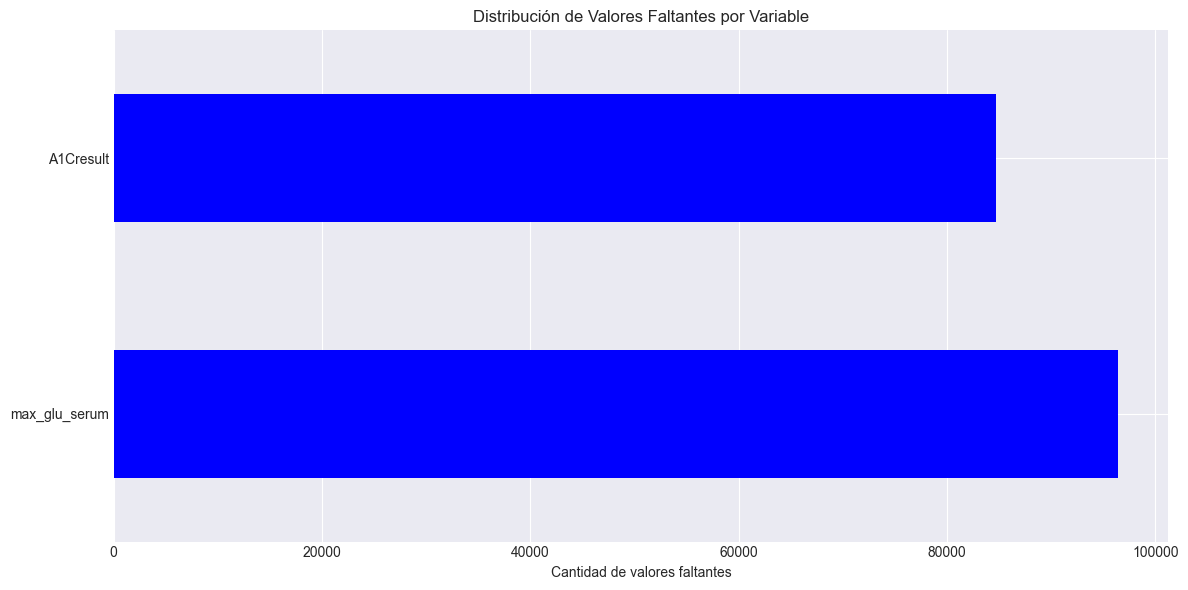

In [ ]:
print("🚨 ANÁLISIS DE VALORES FALTANTES")
print("="*80)

missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

if len(missing_count) > 0:
    missing_df = missing_count.to_frame("Missing_Count")
    missing_df["Missing_Percentage"] = missing_df["Missing_Count"] / len(df) * 100
    print("\nVariables con valores faltantes:")
    print(missing_df.to_string(index=True))
else:
    print("✓ No hay valores faltantes en el dataset")

fig, ax = plt.subplots(figsize=(12, 6))
if len(missing_count) > 0:
    missing_count.plot(kind="barh", ax=ax, color="blue")
    ax.set_xlabel("Cantidad de valores faltantes")
    ax.set_title("Distribución de Valores Faltantes por Variable")
    plt.tight_layout()
    plt.show()
else:
    print("No hay gráfico que mostrar (sin valores faltantes)")